# CV Project notebook
This notebook aims to train a CNN to perform image recolorization

First off, we import the required libraries and files:

In [1]:
extract = False  # set to True to continue extracting files

import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import tqdm
import random
import sys
import tarfile
import pandas as pd

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Autoreload is currently incompatible with Python 3.12 in this environment due to 'imp' removal
# %load_ext autoreload
# %autoreload 2

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Adding the dataloader: load the file to train the model

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
import cv2
import torch
import tqdm


#plots some images
def PlotImages(path, gridSize = (4, 4)):

   #Retrieve all the images in the folder and randomly choose few
   imgs = [f for f in os.listdir(f'{path}') if f.endswith('.jpg')]

   numImgs = gridSize[0] * gridSize[1]
   sampleImages = random.sample(imgs, numImgs)

   #plots
   fig, axs = plt.subplots(gridSize[0], gridSize[1], figsize = (8, 8))
   axs = axs.flatten()

   for i, imgName in enumerate(sampleImages):
      imgPath = os.path.join(f'{path}', imgName)
      img = Image.open(imgPath)

      axs[i].imshow(img)
      axs[i].axis('off')

   plt.tight_layout()
   plt.show()

# function to plot sample
def plot_sample(loader):
   # Grab one batch
   tensor_l, tensor_ab = next(iter(loader))

   # Take first image in batch
   l  = tensor_l[0]   # shape (1, H, W)
   ab = tensor_ab[0]  # shape (2, H, W)

   # --- Denormalize ---
   l_np  = ((l.squeeze(0).numpy() + 1.0) * 128.0)          # [0, 255]
   ab_np = (ab.permute(1, 2, 0).numpy() * 255.0)      # [0, 255]

   # --- Reconstruct Lab and convert back to RGB ---
   lab = np.zeros((*l_np.shape, 3), dtype=np.float32)
   lab[:, :, 0]  = l_np
   lab[:, :, 1:] = ab_np
   lab = lab.astype(np.uint8)
   rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

   # --- Plot ---
   fig, axes = plt.subplots(1, 3, figsize=(12, 4))

   axes[0].imshow(l_np, cmap='gray')
   axes[0].set_title('L channel (Grayscale)')

   axes[1].imshow(rgb)
   axes[1].set_title('Original')

   # Quick AB preview: stack a neutral L with the AB channels
   ab_preview = np.zeros_like(lab)
   ab_preview[:, :, 0]  = 128   # neutral grey lightness
   ab_preview[:, :, 1:] = ab_np.astype(np.uint8)
   axes[2].imshow(cv2.cvtColor(ab_preview, cv2.COLOR_LAB2RGB))
   axes[2].set_title('AB channels (colour info)')

   for ax in axes:
      ax.axis('off')

   plt.tight_layout()
   plt.show()



In [3]:
#define the path for each folder
valPath = "test_256"

In [4]:
class DatasetDecolorization(Dataset):

   def __init__(self, dataDir, transform = None):

      #self.dataDir = os.path.join('/content/drive/MyDrive/CV_project', dataDir)
      self.dataDir = dataDir
      self.imageFiles = []
      self.transform = transform


      #recursively walk in the folder (images in train folder are nested)
      for root, dirs, files in os.walk(dataDir):
        for file in files:
          if file.endswith('.jpg'):
            self.imageFiles.append(os.path.join(root, file))

   def __len__(self):
      return len(self.imageFiles)

   def __getitem__(self, idx):

      #Takes image[idx]
      imgPath = self.imageFiles[idx]
      img = cv2.imread(imgPath)

      #Ensure RGB images
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

      if self.transform:
         img = self.transform(img)
         img = np.array(img)

      #Convert in Lab formt
      imgLab = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2LAB)


      #Split and normalize in range [-1, 1]
      # FIXED NORMALIZATION
      channel_L = imgLab[:, :, 0].astype(np.float32) / 128 - 1.0
      channel_ab = imgLab[:, :, 1:].astype(np.float32)/255.0

      #Convert to tensor
      tensor_l = torch.from_numpy(channel_L).float().unsqueeze(0)
      tensor_ab = torch.from_numpy(channel_ab).float().permute(2, 0, 1)

      return tensor_l, tensor_ab

In [5]:
#TEST
# !cp /content/drive/MyDrive/CV_project/Datasets/val_256.tar /content/
# !mkdir -p /content/TEST
# !tar -xf /content/val_256.tar -C /content/TEST

# valPath = '/content/TEST/val_256'


valDataset = DatasetDecolorization(dataDir = valPath)
valLoader = DataLoader(valDataset, batch_size = 256, shuffle=True, num_workers=0)

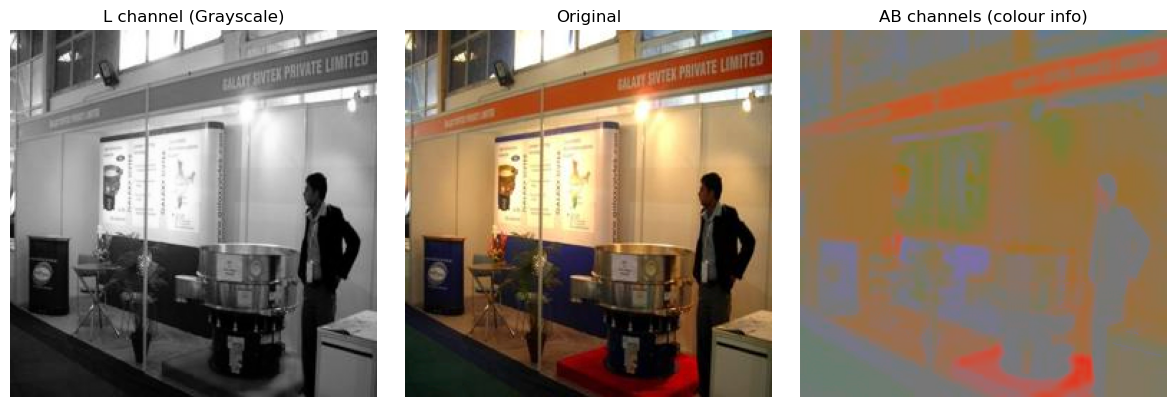

In [6]:
plot_sample(valLoader)

In [ ]:
##Try adding dropout layers

from base_color import *

class ECCVGenerator(BaseColor):
   def __init__(self, norm_layer=nn.BatchNorm2d):
      super(ECCVGenerator, self).__init__()

      model1=[nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=True),]
      model1+=[nn.ReLU(True),]
      model1+=[nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1, bias=True),]
      model1+=[nn.ReLU(True),]
      model1+=[norm_layer(64),]

      model2=[nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1, bias=True),]
      model2+=[nn.ReLU(True),]
      model2+=[nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1, bias=True),]
      model2+=[nn.ReLU(True),]
      model2+=[norm_layer(128),]

      model3=[nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1, bias=True),]
      model3+=[nn.ReLU(True),]
      model3+=[nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=True),]
      model3+=[nn.ReLU(True),]
      model3+=[nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1, bias=True),]
      model3+=[nn.ReLU(True),]
      model3+=[norm_layer(256),]

      model4=[nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1, bias=True),]
      model4+=[nn.ReLU(True),]
      model4+=[nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=True),]
      model4+=[nn.ReLU(True),]
      model4+=[nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=True),]
      model4+=[nn.ReLU(True),]
      model4+=[norm_layer(512),]

      model5=[nn.Conv2d(512, 512, kernel_size=3, dilation=2, stride=1, padding=2, bias=True),]
      model5+=[nn.ReLU(True),]
      model5+=[nn.Conv2d(512, 512, kernel_size=3, dilation=2, stride=1, padding=2, bias=True),]
      model5+=[nn.ReLU(True),]
      model5+=[nn.Conv2d(512, 512, kernel_size=3, dilation=2, stride=1, padding=2, bias=True),]
      model5+=[nn.ReLU(True),]
      model5+=[norm_layer(512),]

      model6=[nn.Conv2d(512, 512, kernel_size=3, dilation=2, stride=1, padding=2, bias=True),]
      model6+=[nn.ReLU(True),]
      model6+=[nn.Conv2d(512, 512, kernel_size=3, dilation=2, stride=1, padding=2, bias=True),]
      model6+=[nn.ReLU(True),]
      model6+=[nn.Conv2d(512, 512, kernel_size=3, dilation=2, stride=1, padding=2, bias=True),]
      model6+=[nn.ReLU(True),]
      model6+=[norm_layer(512),]

      model7=[nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=True),]
      model7+=[nn.ReLU(True),]
      model7+=[nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=True),]
      model7+=[nn.ReLU(True),]
      model7+=[nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=True),]
      model7+=[nn.ReLU(True),]
      model7+=[norm_layer(512),]

      model8=[nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=True),]
      model8+=[nn.ReLU(True),]
      model8+=[nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=True),]
      model8+=[nn.ReLU(True),]
      model8+=[nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=True),]
      model8+=[nn.ReLU(True),]

      model8+=[nn.Conv2d(256, 313, kernel_size=1, stride=1, padding=0, bias=True),]

      self.model1 = nn.Sequential(*model1)
      self.model2 = nn.Sequential(*model2)
      self.model3 = nn.Sequential(*model3)
      self.model4 = nn.Sequential(*model4)
      self.model5 = nn.Sequential(*model5)
      self.model6 = nn.Sequential(*model6)
      self.model7 = nn.Sequential(*model7)
      self.model8 = nn.Sequential(*model8)

      self.softmax = nn.Softmax(dim=1)
      self.model_out = nn.Conv2d(313, 2, kernel_size=1, padding=0, dilation=1, stride=1, bias=False)
      self.upsample4 = nn.Upsample(scale_factor=4, mode='bilinear')

   def forward(self, input_l, T = 0.38):
      conv1_2 = self.model1(self.normalize_l(input_l))
      conv2_2 = self.model2(conv1_2)
      conv3_3 = self.model3(conv2_2)
      conv4_3 = self.model4(conv3_3)
      conv5_3 = self.model5(conv4_3)
      conv6_3 = self.model6(conv5_3)
      conv7_3 = self.model7(conv6_3)
      conv8_3 = self.model8(conv7_3)
    
      out_reg = self.model_out(self.softmax(conv8_3 / T))

      return self.unnormalize_ab(self.upsample4(out_reg))



   def eccv16(pretrained=True):
      model = ECCVGenerator()
      if(pretrained):
         import torch.utils.model_zoo as model_zoo
         model.load_state_dict(model_zoo.load_url('https://colorizers.s3.us-east-2.amazonaws.com/colorization_release_v2-9b330a0b.pth',map_location='cpu',check_hash=True))
      return model


# Test

In [8]:
D_model = ECCVGenerator().eccv16().eval()

# Grab one batch
L = []

for i in range(5):
   tensor_l, tensor_ab = next(iter(valLoader))

   l_batched = tensor_l[0].unsqueeze(0)

   L.append(l_batched)

predA, predB = [], []

for i in range(len(L)):
   with torch.no_grad():

      L_m = (L[i] + 1.0) * 50.0
      T_A =  np.clip(np.random.normal(0.3, 0.1), 0.01, 1)
      T_B =  np.clip(np.random.normal(0.8, 0.1), 0.01, 1)
      prediction_A = D_model(L_m, T= T_A)
      prediction_B = D_model(L_m, T = T_B) 

      predA.append(prediction_A)
      predB.append(prediction_B)

In [9]:
def PrintComparison(L, Pred1, Pred2):

   #Converts L in numpy
   l_np = (L.detach().cpu().squeeze().numpy() + 1.0) * 128.0
   l_np = np.clip(l_np, 0, 255)

   #Pred1 conversion
   ab_np1 = (Pred1.detach().cpu().squeeze(0).permute(1, 2, 0).numpy() + 128)
   ab_np1 = np.clip(ab_np1, 0, 255)

   ab_np2 = (Pred2.detach().cpu().squeeze(0).permute(1, 2, 0).numpy() + 128)
   ab_np2 = np.clip(ab_np2, 0, 255)


   def ToRGB(l, ab):
      lab = np.zeros((*l.shape, 3), dtype=np.uint8)
      lab[:, :, 0]  = l.astype(np.uint8)
      lab[:, :, 1:] = ab.astype(np.uint8)
      return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

   rgb1 = ToRGB(l_np, ab_np1)
   rgb2 = ToRGB(l_np, ab_np2)

   fig, axes = plt.subplots(1, 2, figsize=(9, 4))
   axes[0].imshow(rgb1)
   axes[0].set_title('Input Image1')
   axes[1].imshow(rgb2)
   axes[1].set_title('Input Image2')
   for ax in axes: ax.axis('off')
   plt.tight_layout()
   plt.show()


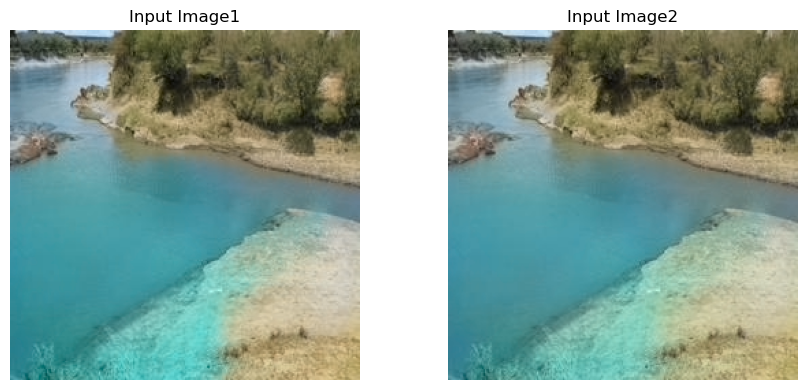

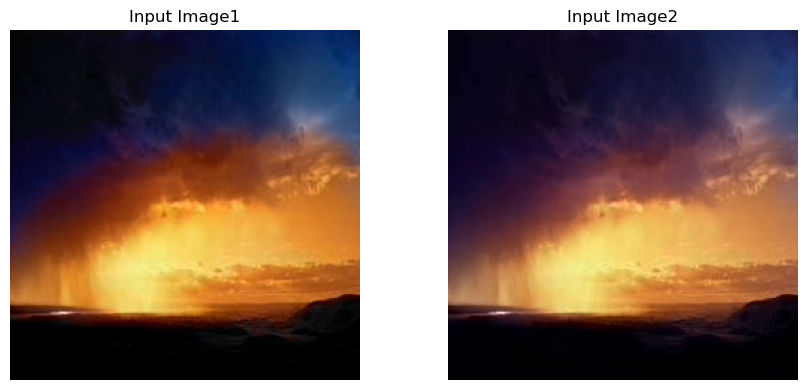

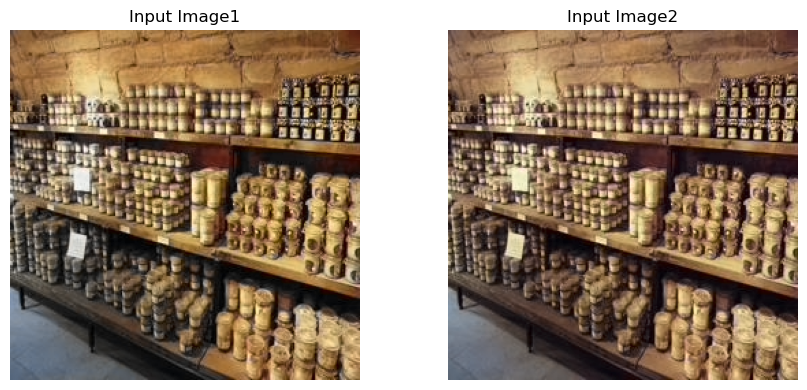

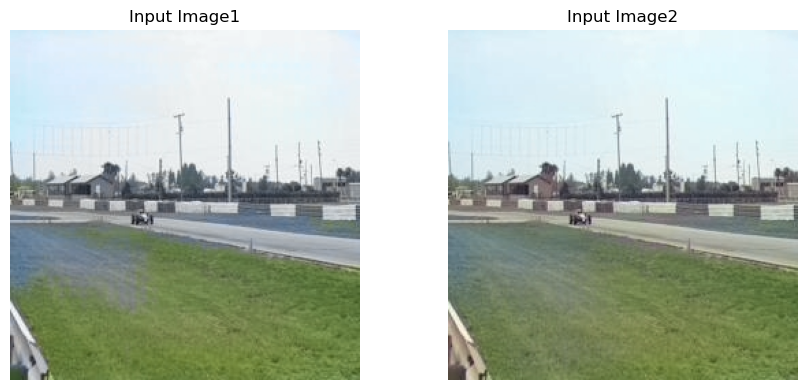

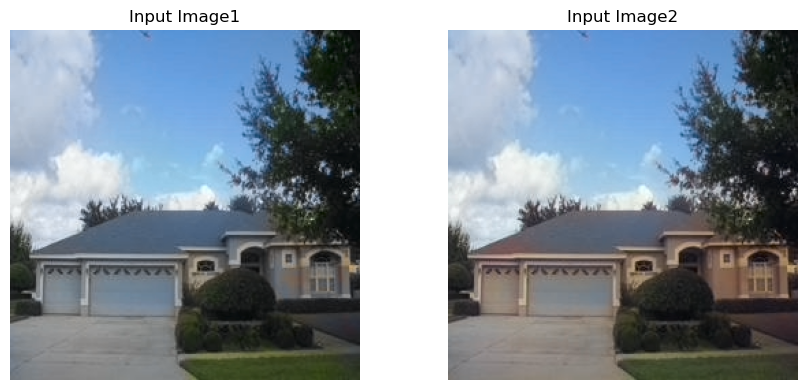

In [10]:
for i in range(len(L)):
   PrintComparison(L[i], predA[i], predB[i])

# Save in Folder

Save images in local to train DPO

In [11]:
def ReturnRGB(L, Pred1, Pred2 = None):

   #Converts L in numpy
   l_np = (L.detach().cpu().squeeze().numpy() + 1.0) * 128.0
   l_np = np.clip(l_np, 0, 255)

   #Pred1 conversion
   ab_np1 = (Pred1.detach().cpu().squeeze(0).permute(1, 2, 0).numpy() + 128)
   ab_np1 = np.clip(ab_np1, 0, 255)

   #Allows to return only 1 value as output
   if Pred2 is not None:
      ab_np2 = (Pred2.detach().cpu().squeeze(0).permute(1, 2, 0).numpy() + 128)
      ab_np2 = np.clip(ab_np2, 0, 255)
   else:
      ab_np2 = None


   def ToRGB(l, ab):
      if ab is None:
         return None
   
      else:
         lab = np.zeros((*l.shape, 3), dtype=np.uint8)
         lab[:, :, 0]  = l.astype(np.uint8)
         lab[:, :, 1:] = ab.astype(np.uint8)
         return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

   rgb1 = ToRGB(l_np, ab_np1)
   rgb2 = ToRGB(l_np, ab_np2)

   return rgb1, rgb2



def TensorToRGB(L_tensor, ab_tensor, isModelOutput=True):
   # L is in [-1, 1] -> shift to [0, 255]
   l_np = (L_tensor.detach().cpu().squeeze().numpy() + 1.0) * 128.0
   l_np = np.clip(l_np, 0, 255).astype(np.uint8)
   
   ab_np = ab_tensor.detach().cpu().squeeze().permute(1, 2, 0).numpy()
   
   if isModelOutput:
      #Model outputs are centered around 0. Shift them to 0-255.
      ab_np = ab_np + 128.0
   else:
      #True AB is in [0, 1] from the dataloader. Scale it to 0-255.
      ab_np = ab_np * 255.0
      
   ab_np = np.clip(ab_np, 0, 255).astype(np.uint8)
   
   # Merge and convert
   lab = np.zeros((l_np.shape[0], l_np.shape[1], 3), dtype=np.uint8)
   lab[:, :, 0] = l_np
   lab[:, :, 1:] = ab_np
   return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

In [12]:
#baseline model
sys.path.append('colorization')
import colorizers

baselineModel = colorizers.eccv16().eval()
D_model = ECCVGenerator.eccv16().eval()

csvData = []
N = 800
totGenerated = 0


tensor_l, tensor_ab = next(iter(valLoader))

#for batch_l, batch_ab in valLoader:

for batch_l, batch_ab in valLoader:
    
   for i in tqdm.tqdm(range(batch_l.size(0))):

      if totGenerated >= N:
         break

      L = batch_l[i].unsqueeze(0)
      true_ab = batch_ab[i].unsqueeze(0)

      with torch.no_grad():

         T_A =  np.clip(np.random.normal(0.3, 0.1), 0.01, 1)
         T_B =  np.clip(np.random.normal(0.8, 0.1), 0.01, 1)
         
         L_m = (L + 1.0) * 50.0
         prediction_A = D_model(L_m, T_A)
         prediction_B = D_model(L_m, T_B)

         baselinePred = baselineModel(L_m)



      #Save images for the human feedback
      rgb_A = TensorToRGB(L, prediction_A, isModelOutput=True)
      rgb_B = TensorToRGB(L, prediction_B, isModelOutput=True)
      rgb_baseline = TensorToRGB(L, baselinePred, isModelOutput=True)
      rgb_True = TensorToRGB(L, true_ab, isModelOutput=False) 


      #Save paths
      imgPathA = f'DPO_dataset/Img_A/A_{totGenerated}.png'
      imgPathB = f'DPO_dataset/Img_B/B_{totGenerated}.png'

      imgPathTrue = f'DPO_dataset/Img_true/Real_{totGenerated}.png'
      imgPathBaseline = f'DPO_dataset/Img_baseline/Baseline_{totGenerated}.png'

      cv2.imwrite(imgPathA, cv2.cvtColor(rgb_A, cv2.COLOR_RGB2BGR))
      cv2.imwrite(imgPathB, cv2.cvtColor(rgb_B, cv2.COLOR_RGB2BGR))
      cv2.imwrite(imgPathTrue, cv2.cvtColor(rgb_True, cv2.COLOR_RGB2BGR))
      cv2.imwrite(imgPathBaseline, cv2.cvtColor(rgb_baseline, cv2.COLOR_RGB2BGR))



      #Log to CSV
      csvData.append({
         'ImageID': totGenerated,
         '(T_A, T_B)': (T_A, T_B),
         'optA_img': imgPathA,
         'optB_img': imgPathB,
         'true_img': imgPathTrue,
         'baseline_img': imgPathBaseline,

         #Human choice is either A or B
         'humanChoice': '',
         'rejectionChoice': ''
      })

      totGenerated += 1

   if totGenerated >= N:
      break

df = pd.DataFrame(csvData)
df.to_csv("DPO_dataset/CSV_log.csv", index=False)


 12%|█▎        | 32/256 [00:21<02:30,  1.49it/s]


# Train the DPO model

Load the FinalResults (already merged) and train the dpo model (DONE IN DPO on ECCV)

# Load the trained model and test it